In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import pickle
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error



warnings.filterwarnings('ignore')

In [2]:
# STEP 1: LOAD THE DATA

df = pd.read_csv('energy_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
# set index properly
df = df.sort_values('time')
df = df.set_index('time')


In [3]:
print("\n[STEP 5] Creating generation features...")

# =========================
#  RENEWABLE ENERGY
# =========================
df['renewable'] = (
    df['generation solar'].fillna(0) +
    df['generation wind onshore'].fillna(0) +
    df['generation hydro run-of-river and poundage'].fillna(0) +
    df['generation hydro water reservoir'].fillna(0) +
    df['generation hydro pumped storage consumption'].fillna(0) +  # part of hydro system
    df['generation biomass'].fillna(0) +
    df['generation other renewable'].fillna(0)
)

# =========================
#  FOSSIL FUELS
# =========================
df['fossil'] = (
    df['generation fossil gas'].fillna(0) +
    df['generation fossil hard coal'].fillna(0) +
    df['generation fossil brown coal/lignite'].fillna(0) +
    df['generation fossil oil'].fillna(0) 

    )

# =========================
#  NUCLEAR
# =========================
df['nuclear'] = df['generation nuclear'].fillna(0)

# =========================
#  OTHER / MISC
# =========================
df['other'] = (
    df['generation other'].fillna(0) +
    df['generation waste'].fillna(0)
)


# =========================
# TOTAL GENERATION
# =========================
df['total_gen'] = (
    df['renewable'] +
    df['fossil'] +
    df['nuclear'] +
    df['other']
)


[STEP 5] Creating generation features...


In [4]:

summary = pd.DataFrame({
    'zeros': (df == 0).sum(),
    'non_zeros': (df != 0).sum()
})

print(summary.sort_values('zeros', ascending=False))

                                             zeros  non_zeros
generation fossil coal-derived gas           35046         18
generation wind offshore                     35046         18
generation geothermal                        35046         18
generation fossil peat                       35046         18
generation fossil oil shale                  35046         18
generation marine                            35045         19
generation hydro pumped storage consumption  12607      22457
generation fossil brown coal/lignite         10517      24547
forecast solar day ahead                       539      34525
renewable                                       21      35043
other                                           21      35043
nuclear                                         20      35044
fossil                                          18      35046
total_gen                                       17      35047
generation biomass                               4      35060
generati

In [5]:
# STEP 2: DROP USELESS COLUMNS

columns_to_drop = [
    'generation hydro pumped storage aggregated',
    'generation geothermal',
    'generation marine',
    'forecast wind offshore day ahead',
    'generation other',
    'generation other renewable',
    'generation fossil oil',
    'generation fossil oil shale',
    'generation fossil peat',
    'generation wind offshore',
    'generation fossil coal-derived gas',
    'forecast wind offshore eday ahead',
   
    #'price day ahead',
    'generation solar',
    'generation wind onshore',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation biomass',
    'generation other renewable',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil brown coal/lignite',
    'generation fossil oil',
    'generation nuclear',
    'generation other',
    'generation waste'

]

df = df.drop(columns=columns_to_drop, errors='ignore')


In [6]:
# STEP 3: CREATE TIME FEATURES (FIXED!)

df['hour'] = df.index.hour                    # 0-23
df['day_of_week'] = df.index.dayofweek       # 0-6
df['month'] = df.index.month                 # 1-12
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# DON'T DROP HOUR - You use it in STEP 10!

# Weekend flag
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)




In [7]:
# STEP 4: CREATE LAG FEATURES (Past Values)

# Past demand values
df['demand_lag_1h'] = df['total load actual'].shift(1)      # 1 hour ago
df['demand_lag_24h'] = df['total load actual'].shift(24)    # Yesterday same hour
df['demand_lag_168h'] = df['total load actual'].shift(168)  # Last week

# Past price values
df['price_lag_1h'] = df['price actual'].shift(1)            # 1 hour ago
df['price_lag_24h'] = df['price actual'].shift(24)          # Yesterday

In [8]:
# STEP 6: CREATE  RATIOS

df['renewable_pct'] = np.where(
    df['total_gen'] > 0,
    (df['renewable'] / df['total_gen']) * 100,
    0
)

In [9]:
# STEP 7: CREATE ROLLING AVERAGES


# Average demand over last 24 hours
df['demand_avg_24h'] = df['total load actual'].rolling(window=24, min_periods=1).mean()

# Average price over last 24 hours
df['price_avg_24h'] = df['price actual'].rolling(window=24, min_periods=1).mean()


In [10]:
# STEP 8: REMOVE EMPTY ROWS

# From lag features, first few rows will be empty
rows_before = len(df)
df = df.dropna(subset=['demand_lag_168h', 'price_lag_24h'])  # Only drop rows missing lag features
rows_after = len(df)
rows_removed = rows_before - rows_after

In [11]:
# Drop columns that contain ALL zeros
zero_cols = df.columns[(df == 0).all()]
print("Dropping the following all-zero columns:", zero_cols.tolist())
df = df.drop(zero_cols, axis=1)

Dropping the following all-zero columns: []


In [12]:


#checking for outliers in  actual column
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} outliers")
    return len(outliers)
count_outliers(df, 'price actual')
count_outliers(df, 'total load actual')
def outlier_percentage(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    percent = (len(outliers) / len(df)) * 100
    print(f"{col}: {percent:.2f}% outliers")

price actual: 697 outliers
total load actual: 0 outliers


In [13]:

from sklearn.preprocessing import RobustScaler

scaler_price = RobustScaler()
scaler_demand = RobustScaler()

df['price_scaled'] = scaler_price.fit_transform(df[['price actual']])
df['demand_scaled'] = scaler_demand.fit_transform(df[['total load actual']])


In [14]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print("Dropping constant columns:", constant_columns)
df = df.drop(columns=constant_columns)

Dropping constant columns: []


In [64]:

#STEP 10: SELECT FEATURES FOR MODELS

demand_features = [
    # time
    'hour', 'day_of_week', 'month', 'is_weekend',

    # lag demand
    'demand_lag_1h',
    'demand_lag_24h',
    'demand_lag_168h',

    # lag price
    'price_lag_1h',
    'price_lag_24h',

    # generation
    'renewable', 'fossil', 'nuclear',

    # system state
    'renewable_pct',

    # rolling
    'demand_avg_24h',
    'price_avg_24h',
    'forecast wind onshore day ahead',
    'forecast solar day ahead',

    #  NEW (future signal)
    'total load forecast'
]



price_features = [
    # time
    'hour', 'day_of_week', 'month', 'is_weekend',

    # price history
    'price_lag_1h',
    'price_lag_24h',

    # demand influence
    'demand_lag_1h',
    'demand_lag_24h',
    'forecast wind onshore day ahead',
    'forecast solar day ahead',

    # generation
    'renewable', 'fossil', 'nuclear',

    # system balance
    'renewable_pct',

    # rolling
    'price_avg_24h',
    'demand_avg_24h',

    #  NEW
    'total load forecast',
    'price day ahead'
]


In [16]:

y_demand = 'total load actual'
y_price = 'price actual'


In [17]:
# ==========================================
# CRITICAL CORRECTION: PREVENTING DATA LEAKAGE
# ==========================================
df['demand_avg_24h'] = df['total load actual'].rolling(window=24, min_periods=1).mean().shift(1)
df['price_avg_24h'] = df['price actual'].rolling(window=24, min_periods=1).mean().shift(1)

# ==========================================
# THE FINAL PURGE: REMOVING ALL HIDDEN NaNs
# ==========================================
# Combine all features we care about into one list
all_required_columns = list(set(demand_features + price_features + ['total load actual', 'price actual']))

# Drop any row that is missing data in ANY of these columns
rows_before = len(df)
df = df.dropna(subset=all_required_columns).copy()
print(f"Purged {rows_before - len(df)} imperfect rows. Dataset is now perfectly sanitized.")

# ==========================================
# STEP 11: DEFINE MATRICES AND TARGETS
# ==========================================
X_demand = df[demand_features]
y_demand = df['total load actual']

X_price = df[price_features]
y_price = df['price actual']

# ==========================================
# STEP 12: CHRONOLOGICAL TRAIN-TEST SPLIT
# ==========================================
split = int(len(df) * 0.8)

# Split Demand Data
X_train_d = X_demand.iloc[:split]
X_test_d  = X_demand.iloc[split:]
y_train_d = y_demand.iloc[:split]
y_test_d  = y_demand.iloc[split:]

# Split Price Data
X_train_p = X_price.iloc[:split]
X_test_p  = X_price.iloc[split:]
y_train_p = y_price.iloc[:split]
y_test_p  = y_price.iloc[split:]

print(f"Demand Split - Training Records: {len(X_train_d)}, Testing Records: {len(X_test_d)}")
print(f"Price Split  - Training Records: {len(X_train_p)}, Testing Records: {len(X_test_p)}")

Purged 82 imperfect rows. Dataset is now perfectly sanitized.
Demand Split - Training Records: 27822, Testing Records: 6956
Price Split  - Training Records: 27822, Testing Records: 6956


--- LEVEL 1: LINEAR REGRESSION BASELINE ---

Training Linear Regression on Demand Data...
[DEMAND FORECASTING RESULTS]
MAE:  265.70 MW
RMSE: 374.49 MW
MAPE: 0.92%
R2:   0.9931

Training Linear Regression on Price Data...
[PRICE FORECASTING RESULTS]
MAE:  €1.67
RMSE: €2.33
MAPE: 2.80%
R2:   0.9587

--- PURE PROPORTION (0 to 1 SCALE) ---
Demand NMAE:  0.0092
Demand NRMSE: 0.0130
Price NMAE:   0.0256
Price NRMSE:  0.0358


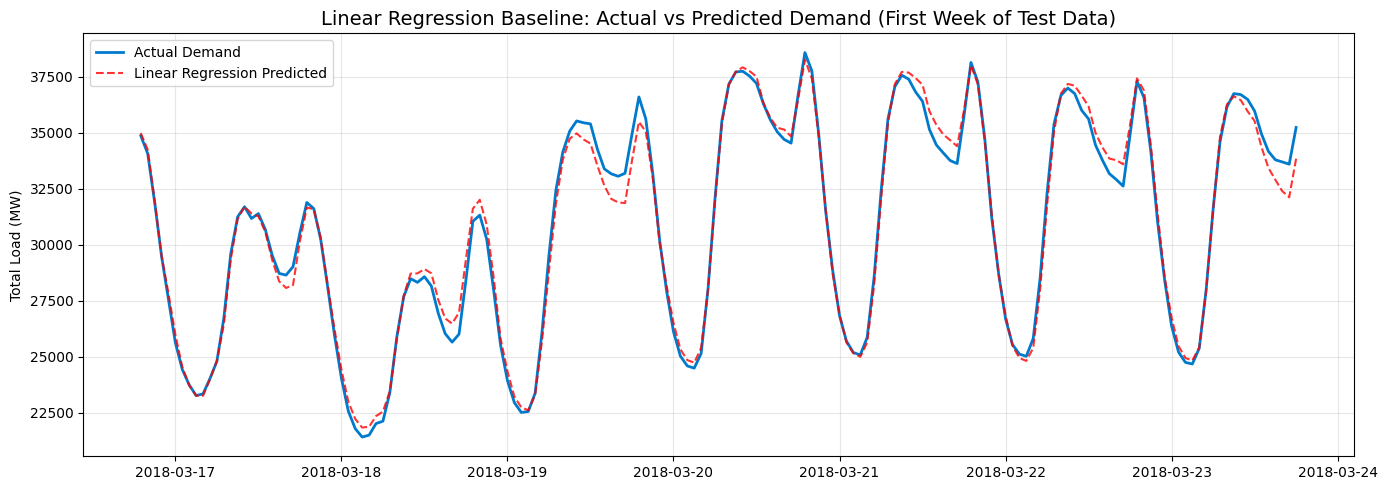

In [19]:
print("--- LEVEL 1: LINEAR REGRESSION BASELINE ---\n")

# ==========================================
# 1. TRAIN AND EVALUATE: DEMAND
# ==========================================
# Initialize the model
lr_demand = LinearRegression()

# Train the model
print("Training Linear Regression on Demand Data...")
lr_demand.fit(X_train_d, y_train_d)

# Predict the future using the test features
y_pred_d_lr = lr_demand.predict(X_test_d)

# Calculate Evaluation Metrics
mae_d = mean_absolute_error(y_test_d, y_pred_d_lr)
rmse_d = np.sqrt(mean_squared_error(y_test_d, y_pred_d_lr))
mape_d = mean_absolute_percentage_error(y_test_d, y_pred_d_lr) * 100
r2_d = r2_score(y_test_d, y_pred_d_lr)

print("[DEMAND FORECASTING RESULTS]")
print(f"MAE:  {mae_d:.2f} MW")
print(f"RMSE: {rmse_d:.2f} MW")
print(f"MAPE: {mape_d:.2f}%")
print(f"R2:   {r2_d:.4f}\n")

# ==========================================
# 2. TRAIN AND EVALUATE: PRICE
# ==========================================
# Initialize the model
lr_price = LinearRegression()

# Train the model
print("Training Linear Regression on Price Data...")
lr_price.fit(X_train_p, y_train_p)

# Predict the future using the test features
y_pred_p_lr = lr_price.predict(X_test_p)

# Calculate Evaluation Metrics
mae_p = mean_absolute_error(y_test_p, y_pred_p_lr)
rmse_p = np.sqrt(mean_squared_error(y_test_p, y_pred_p_lr))
mape_p = mean_absolute_percentage_error(y_test_p, y_pred_p_lr) * 100
r2_p = r2_score(y_test_p, y_pred_p_lr)

print("[PRICE FORECASTING RESULTS]")
print(f"MAE:  €{mae_p:.2f}")
print(f"RMSE: €{rmse_p:.2f}")
print(f"MAPE: {mape_p:.2f}%")
print(f"R2:   {r2_p:.4f}\n")
# ==========================================
# NORMALIZED METRICS (0 to 1 Scale)
# ==========================================
# Calculate the mean (average) of the actual test data
mean_demand = y_test_d.mean()
mean_price = y_test_p.mean()

# Normalize the errors
nmae_d = mae_d / mean_demand
nrmse_d = rmse_d / mean_demand

nmae_p = mae_p / mean_price
nrmse_p = rmse_p / mean_price

print("--- PURE PROPORTION (0 to 1 SCALE) ---")
print(f"Demand NMAE:  {nmae_d:.4f}")
print(f"Demand NRMSE: {nrmse_d:.4f}")
print(f"Price NMAE:   {nmae_p:.4f}")
print(f"Price NRMSE:  {nrmse_p:.4f}")

# ==========================================
# 3. VISUALIZE THE BASELINE (DEMAND)
# ==========================================
# Plotting the first 168 hours (Exactly one week) of the test set
plt.figure(figsize=(14, 5))
plt.plot(y_test_d.index[:168], y_test_d.iloc[:168], label='Actual Demand', color='#007acc', linewidth=2)
plt.plot(y_test_d.index[:168], y_pred_d_lr[:168], label='Linear Regression Predicted', color='red', linestyle='--', alpha=0.8)

plt.title("Linear Regression Baseline: Actual vs Predicted Demand (First Week of Test Data)", fontsize=14)
plt.ylabel("Total Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

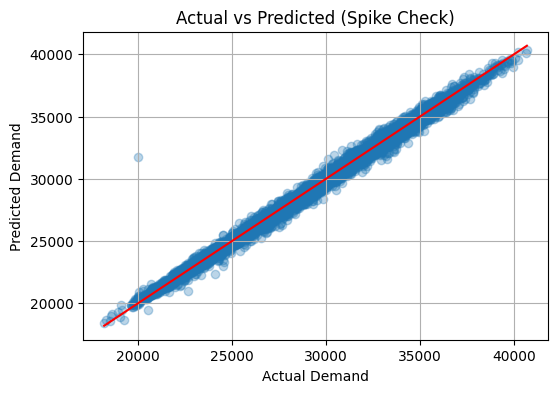

In [20]:
plt.figure(figsize=(6,4))

plt.scatter(y_test_d, y_pred_d_lr, alpha=0.3)

plt.plot([y_test_d.min(), y_test_d.max()],
         [y_test_d.min(), y_test_d.max()],
         color='red')

plt.title("Actual vs Predicted (Spike Check)")
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.grid(True)
plt.show()

In [21]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, r2_score

# ==========================================
# 1. K-NEAREST NEIGHBORS (KNN)
# ==========================================
# KNN is a non-parametric model that predicts based on the 'k' most similar historical hours.
# Note: n_neighbors=5 is a standard starting point.
knn_demand = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn_price = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)

print("--- TRAINING K-NEAREST NEIGHBORS ---")
knn_demand.fit(X_train_d, y_train_d)
knn_price.fit(X_train_p, y_train_p)

# Predictions
y_pred_knn_d = knn_demand.predict(X_test_d)
y_pred_knn_p = knn_price.predict(X_test_p)

# ==========================================
# 2. BAYESIAN RIDGE (The Bayesian Regression Choice)
# ==========================================
# This model provides a probabilistic approach to linear regression.
br_demand = BayesianRidge()
br_price = BayesianRidge()

print("--- TRAINING BAYESIAN RIDGE ---")
br_demand.fit(X_train_d, y_train_d)
br_price.fit(X_train_p, y_train_p)

# Predictions
y_pred_br_d = br_demand.predict(X_test_d)
y_pred_br_p = br_price.predict(X_test_p)

# ==========================================
# 3. EVALUATION FUNCTION (Normalized Scale 0 to 1)
# ==========================================
def evaluate_model(y_true, y_pred, name, target_name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nmae = mae / y_true.mean() # Standardized 0 to 1 scale
    print(f"[{target_name} | {name}] R2: {r2:.4f} | NMAE: {nmae:.4f}")

print("\n--- FINAL COMPARATIVE RESULTS ---")
evaluate_model(y_test_d, y_pred_knn_d, "KNN", "DEMAND")
evaluate_model(y_test_d, y_pred_br_d, "Bayesian Ridge", "DEMAND")
print("-" * 30)
evaluate_model(y_test_p, y_pred_knn_p, "KNN", "PRICE")
evaluate_model(y_test_p, y_pred_br_p, "Bayesian Ridge", "PRICE")

--- TRAINING K-NEAREST NEIGHBORS ---
--- TRAINING BAYESIAN RIDGE ---

--- FINAL COMPARATIVE RESULTS ---
[DEMAND | KNN] R2: 0.9834 | NMAE: 0.0151
[DEMAND | Bayesian Ridge] R2: 0.9931 | NMAE: 0.0092
------------------------------
[PRICE | KNN] R2: -0.7166 | NMAE: 0.1915
[PRICE | Bayesian Ridge] R2: 0.9587 | NMAE: 0.0256


In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 1. INITIALIZE MODELS
# ==========================================
# Decision Tree: A single, deep logic structure
dt_demand = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_price = DecisionTreeRegressor(max_depth=10, random_state=42)

# Random Forest: An ensemble of 100 trees
# n_jobs=-1 utilizes all your CPU cores for faster training
rf_demand = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf_price = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)

# ==========================================
# 2. TRAINING
# ==========================================
print("Training Decision Trees...")
dt_demand.fit(X_train_d, y_train_d)
dt_price.fit(X_train_p, y_train_p)

print("Training Random Forests (this may take a moment)...")
rf_demand.fit(X_train_d, y_train_d)
rf_price.fit(X_train_p, y_train_p)

# ==========================================
# 3. EVALUATION
# ==========================================
def report_results(model, X_test, y_test, label, target):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    nmae = mae / y_test.mean()
    print(f"[{target} | {label}] R2: {r2:.4f} | NMAE: {nmae:.4f}")

print("\n--- ENSEMBLE MODEL RESULTS ---")
report_results(dt_demand, X_test_d, y_test_d, "Decision Tree", "DEMAND")
report_results(rf_demand, X_test_d, y_test_d, "Random Forest", "DEMAND")
print("-" * 35)
report_results(dt_price, X_test_p, y_test_p, "Decision Tree", "PRICE")
report_results(rf_price, X_test_p, y_test_p, "Random Forest", "PRICE")

Training Decision Trees...
Training Random Forests (this may take a moment)...

--- ENSEMBLE MODEL RESULTS ---
[DEMAND | Decision Tree] R2: 0.9919 | NMAE: 0.0097
[DEMAND | Random Forest] R2: 0.9939 | NMAE: 0.0084
-----------------------------------
[PRICE | Decision Tree] R2: 0.9252 | NMAE: 0.0346
[PRICE | Random Forest] R2: 0.9595 | NMAE: 0.0266


In [28]:


# ==========================================
# 1. THE 24-HOUR TARGET SHIFT
# ==========================================
# We predict the value 24 hours from 'now'
df['demand_24h_ahead'] = df['total load actual'].shift(-24)
df['price_24h_ahead'] = df['price actual'].shift(-24)

# Drop rows where future data is unknown (the last 24 rows)
df_future = df.dropna(subset=['demand_24h_ahead', 'price_24h_ahead']).copy()

# ==========================================
# 2. DATA SPLITTING
# ==========================================
split = int(len(df_future) * 0.8)

# Demand Data
X_d_f = df_future[demand_features]
y_d_f = df_future['demand_24h_ahead']

# Price Data
X_p_f = df_future[price_features]
y_p_f = df_future['price_24h_ahead']

# Chronological Train/Test
X_train_df, X_test_df = X_d_f.iloc[:split], X_d_f.iloc[split:]
y_train_df, y_test_df = y_d_f.iloc[:split], y_d_f.iloc[split:]

X_train_pf, X_test_pf = X_p_f.iloc[:split], X_p_f.iloc[split:]
y_train_pf, y_test_pf = y_p_f.iloc[:split], y_p_f.iloc[split:]

# ==========================================
# 3. MODEL INITIALIZATION
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=50, n_jobs=-1),
    "Decision Tree": DecisionTreeRegressor(max_depth=20, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=250, max_depth=20, n_jobs=-1, random_state=42)
}

# ==========================================
# 4. EXECUTION & EVALUATION
# ==========================================
print("--- 24-HOUR FORECAST: STRUCTURAL INTEGRITY TEST ---\n")

def run_future_test(target_name, X_train, X_test, y_train, y_test):
    print(f"Target: {target_name}")
    print(f"{'Model':<20} | {'R2 Score':<10} | {'NMAE (0-1)':<10}")
    print("-" * 45)
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        r2 = r2_score(y_test, preds)
        nmae = mean_absolute_error(y_test, preds) / y_test.mean()
        print(f"{name:<20} | {r2:^10.4f} | {nmae:^10.4f}")
    print("\n")

run_future_test("DEMAND (24h Ahead)", X_train_df, X_test_df, y_train_df, y_test_df)
run_future_test("PRICE (24h Ahead)", X_train_pf, X_test_pf, y_train_pf, y_test_pf)


--- 24-HOUR FORECAST: STRUCTURAL INTEGRITY TEST ---

Target: DEMAND (24h Ahead)
Model                | R2 Score   | NMAE (0-1)
---------------------------------------------
Linear Regression    |   0.5751   |   0.0787  
KNN (k=5)            |   0.6212   |   0.0730  
Decision Tree        |   0.5091   |   0.0732  
Random Forest        |   0.7234   |   0.0556  


Target: PRICE (24h Ahead)
Model                | R2 Score   | NMAE (0-1)
---------------------------------------------
Linear Regression    |   0.6550   |   0.0776  
KNN (k=5)            |  -0.6266   |   0.1927  
Decision Tree        |   0.2223   |   0.1156  
Random Forest        |   0.6616   |   0.0772  




In [65]:
# ==========================================
# 1. THE 12-HOUR TARGET SHIFT
# ==========================================
df['demand_12h_ahead'] = df['total load actual'].shift(-12)
df['price_12h_ahead'] = df['price actual'].shift(-12)

# Remove rows without future targets
df_12h = df.dropna(subset=['demand_12h_ahead', 'price_12h_ahead']).copy()

# ==========================================
# 2. DATA SPLITTING (80/20)
# ==========================================
split = int(len(df_12h) * 0.8)

# Features remain the same
X_d_12 = df_12h[demand_features]
y_d_12 = df_12h['demand_12h_ahead']

X_p_12 = df_12h[price_features]
y_p_12 = df_12h['price_12h_ahead']

X_train_d12, X_test_d12 = X_d_12.iloc[:split], X_d_12.iloc[split:]
y_train_d12, y_test_d12 = y_d_12.iloc[:split], y_d_12.iloc[split:]

X_train_p12, X_test_p12 = X_p_12.iloc[:split], X_p_12.iloc[split:]
y_train_p12, y_test_p12 = y_p_12.iloc[:split], y_p_12.iloc[split:]

# ==========================================
# 3. XGBOOST 12-HOUR EVALUATION
# ==========================================
xgb_12h = XGBRegressor(n_estimators=265, learning_rate=0.035, max_depth=6, n_jobs=-1, random_state=42)

def run_12h_test(X_tr, X_te, y_tr, y_te, target_name):
    print(f"Training XGBoost for {target_name}...")
    xgb_12h.fit(X_tr, y_tr)
    preds = xgb_12h.predict(X_te)
    r2 = r2_score(y_te, preds)
    nmae = mean_absolute_error(y_te, preds) / y_te.mean()
    print(f"[12-Hour Ahead | {target_name}] R2: {r2:.4f} | NMAE: {nmae:.4f}")

print("--- EXECUTING 12-HOUR MID-RANGE FORECAST ---")
run_12h_test(X_train_d12, X_test_d12, y_train_d12, y_test_d12, "DEMAND")
run_12h_test(X_train_p12, X_test_p12, y_train_p12, y_test_p12, "PRICE")

--- EXECUTING 12-HOUR MID-RANGE FORECAST ---
Training XGBoost for DEMAND...
[12-Hour Ahead | DEMAND] R2: 0.8099 | NMAE: 0.0485
Training XGBoost for PRICE...
[12-Hour Ahead | PRICE] R2: 0.6954 | NMAE: 0.0741


In [66]:
# 1. Create the 12-Hour Target
# We shift the actual price 12 steps back so that 'today at noon' 
# is aligned with 'midnight's' actual price.
df['price_12h_ahead'] = df['price actual'].shift(-12)

# 2. Select Features
# We include the 'day ahead' forecasts to act as the structural baseline.
features_12h = [
    'price day ahead', 
    'total load forecast',
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
    'hour_sin', 'hour_cos', 
    'day_of_week', 
    'is_weekend'
]

# 3. Clean the Dataset
# Drop the last 12 rows where the target is NaN due to the shift
df_12h = df.dropna(subset=features_12h + ['price_12h_ahead']).copy()

# 4. Chronological Split (80/20)
# Important: Do not use train_test_split(shuffle=True) for time series!
split_idx = int(len(df_12h) * 0.8)

X_train = df_12h[features_12h].iloc[:split_idx]
y_train = df_12h['price_12h_ahead'].iloc[:split_idx]

X_test = df_12h[features_12h].iloc[split_idx:]
y_test = df_12h['price_12h_ahead'].iloc[split_idx:]

# 5. Initialize and Train the Random Forest
# We use n_jobs=-1 to utilize all CPU cores for faster training
rf_12h = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15, 
    random_state=42, 
    n_jobs=-1
)

print("Training 12-Hour Price Prediction Model...")
rf_12h.fit(X_train, y_train)

# 6. Evaluation
preds = rf_12h.predict(X_test)
r2 = r2_score(y_test, preds)
nmae = mean_absolute_error(y_test, preds) / y_test.mean()

print("\n--- 12-HOUR PRICE FORECAST RESULTS ---")
print(f"R2 Score: {r2:.4f}")
print(f"NMAE:     {nmae:.4f}")

Training 12-Hour Price Prediction Model...

--- 12-HOUR PRICE FORECAST RESULTS ---
R2 Score: 0.1142
NMAE:     0.1296


In [ ]:


# 1. Scaling the Features (X)
# This is mandatory for SVM. We use a separate scaler for X.
scaler_X = RobustScaler()
X_cols = features_12h # Using the list we defined earlier

# Fit and transform the training features
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 2. Scaling the Target (y)
# You already initialized 'scaler_price' in your code
# SVR usually performs best when y is also scaled to the same range
y_train_scaled = scaler_price.fit_transform(y_train.values.reshape(-1, 1)).flatten()

# 3. Training the SVR
# C=10 is a good middle ground; epsilon=0.1 allows for a small error margin
svr_final = SVR(kernel='rbf', C=15, epsilon=0.03)
print("Training SVR on robust-scaled features...")
svr_final.fit(X_train_scaled, y_train_scaled)

# 4. Inverse Scaling to get Real Prices
# We must 'un-scale' the prediction to compare it with actual prices
preds_scaled = svr_final.predict(X_test_scaled)
preds_final = scaler_price.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

# 5. Results
r2_svr = r2_score(y_test, preds_final)
print(f"SVR 12-Hour Price R2: {r2_svr:.4f}")

Training SVR on robust-scaled features...


In [61]:

# 1. Target and Feature Alignment
df['demand_12h_ahead'] = df['total load actual'].shift(-12)
features_d = ['total load forecast', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend']
df_d = df.dropna(subset=features_d + ['demand_12h_ahead']).copy()

# 2. Split
split = int(len(df_d) * 0.8)
X_train_d, X_test_d = df_d[features_d].iloc[:split], df_d[features_d].iloc[split:]
y_train_d, y_test_d = df_d['demand_12h_ahead'].iloc[:split], df_d['demand_12h_ahead'].iloc[split:]

# 3. Robust Scaling
scaler_X_d = RobustScaler()
scaler_y_d = RobustScaler()

X_train_sd = scaler_X_d.fit_transform(X_train_d)
X_test_sd = scaler_X_d.transform(X_test_d)
y_train_sd = scaler_y_d.fit_transform(y_train_d.values.reshape(-1, 1)).flatten()

# 4. SVR Model (Optimized for Demand)
svr_demand = SVR(kernel='rbf', C=12, epsilon=0.03)
print("Training SVR for Demand (12h)...")
svr_demand.fit(X_train_sd, y_train_sd)

# 5. Inverse Transform and Evaluate
preds_sd = svr_demand.predict(X_test_sd)
preds_d = scaler_y_d.inverse_transform(preds_sd.reshape(-1, 1)).flatten()

print(f"[SVR | DEMAND | 12-Hour] R2: {r2_score(y_test_d, preds_d):.4f}")

Training SVR for Demand (12h)...
[SVR | DEMAND | 12-Hour] R2: 0.7679
